# Solving Credit Assignment with Reward-Modulated STDP
**Bridging Reinforcement Learning and Spiking Neural Networks via Eligibility Traces**

## 1. Abstract
If an AI agent is to act proactively in an environment, it must learn from delayed consequences. However, Spiking Neural Networks lack backpropagation. If a motor neuron fires and a reward arrives 300 milliseconds later, how does the specific synapse know it was responsible? This simulation solves the Credit Assignment Problem in continuous time using Reward-Modulated STDP (R-STDP), where neurons leave a decaying chemical memory of their activity that is "developed" by delayed global dopamine.

## 2. The Mechanism
Instead of instantaneous weight changes, a spike creates a slow-decaying Eligibility Trace ($E$).
$$\frac{dE}{dt} = -\frac{E}{\tau_E} + \text{Spike}(t)$$

Synaptic weights only change permanently when a global Dopamine signal ($D$) interacts with an active trace.
$$\Delta W = \eta \cdot E(t) \cdot (D(t) - D_{baseline})$$

## 3. Experimental Design
* **The Two-Action Setup:** We simulate two competing Motor Neurons.
    * **Neuron A (Correct):** Fires and triggers a delayed environmental reward (+Dopamine) 300ms later.
    * **Neuron B (Wrong):** Fires but triggers no reward.
* **The Goal:** Prove that the delayed dopamine wave can successfully seek out the active eligibility trace of Neuron A and strengthen its synapse, while Neuron B's synapse naturally decays.

Running Delayed Reward Simulation (R-STDP)...

   REWARD-MODULATED STDP REPORT: [SUCCESS]


,Action,Spike Time,Reward Delay,Initial Weight,Final Weight
0,Motor A (Correct),400 ms,300 ms,2.00,2.43
1,Motor B (Wrong),1400 ms,None,2.00,1.63


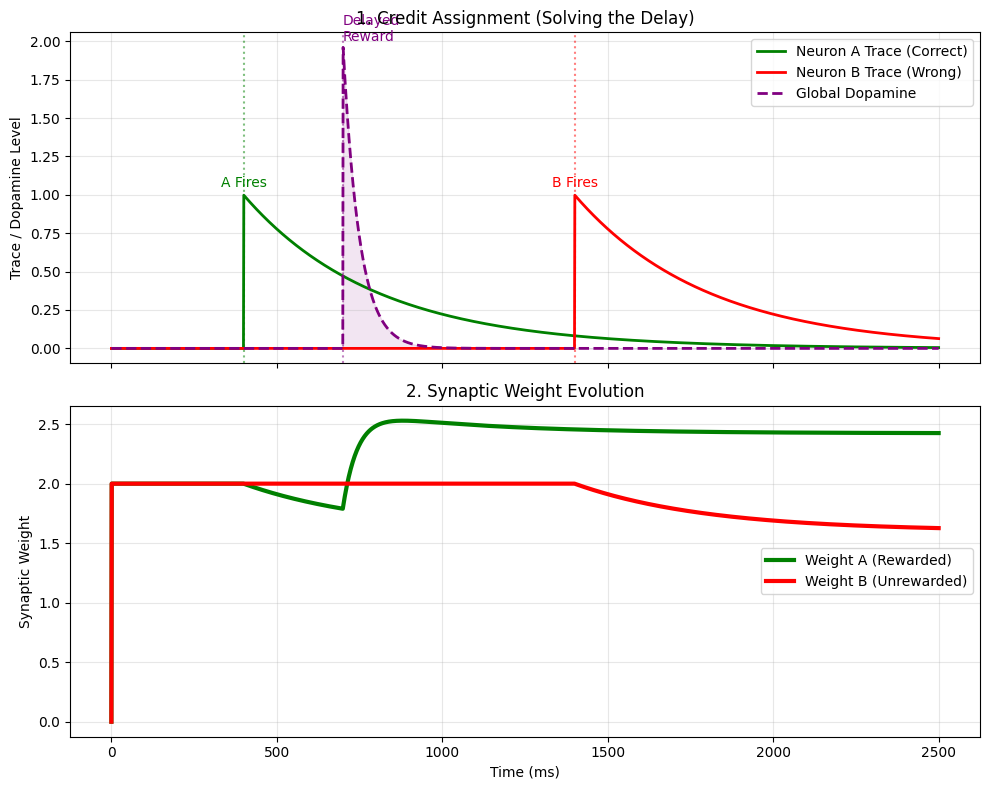

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. CONFIGURATION ---
np.random.seed(42)
T = 2500            # 2.5 seconds
dt = 1.0
time = np.arange(T) * dt

# LIF Parameters
tau_m = 20.0
v_rest = -70.0
v_reset = -70.0
v_thresh = -50.0

# Plasticity & Trace Parameters
eta = 0.02                 # Learning Rate
tau_eligibility = 400.0    # Slow chemical trace (lasts hundreds of ms)
tau_dopamine = 50.0        # Dopamine clears quickly once released
d_baseline = -0.05         # Slight constant penalty if no reward arrives
w_max = 10.0

# --- 2. SETUP ---
# Two synapses competing: W_A (Correct) and W_B (Wrong)
w_A = 2.0; w_B = 2.0
w_A_hist = np.zeros(T); w_B_hist = np.zeros(T)

e_A = 0.0; e_B = 0.0     # Eligibility Traces
e_A_hist = np.zeros(T); e_B_hist = np.zeros(T)

dopamine = 0.0
dopamine_hist = np.zeros(T)

# To prove the math, we force the actions:
# Neuron A (Correct) fires at t=400. Reward arrives at t=700 (300ms delay).
# Neuron B (Wrong) fires at t=1400. No reward arrives.
spike_A_time = 400
reward_time = 700
spike_B_time = 1400

# --- 3. SIMULATION LOOP ---
print("Running Delayed Reward Simulation (R-STDP)...")

for t in range(1, T):
    # 1. Simulate Spikes (Leaving the chemical trace)
    if t == spike_A_time:
        e_A += 1.0  # Neuron A fired! Leaves a trace.
    if t == spike_B_time:
        e_B += 1.0  # Neuron B fired! Leaves a trace.

    # 2. Simulate Delayed Environment Reward
    if t == reward_time:
        dopamine += 2.0  # The environment delivers a delayed reward

    # 3. Decay the Traces and Dopamine
    e_A += (-e_A / tau_eligibility) * dt
    e_B += (-e_B / tau_eligibility) * dt
    dopamine += (-dopamine / tau_dopamine) * dt

    # Trackers
    e_A_hist[t] = e_A
    e_B_hist[t] = e_B
    dopamine_hist[t] = dopamine

    # 4. R-STDP Weight Update Rule
    # Weight changes based on Trace * (Dopamine - Baseline)
    dw_A = eta * e_A * (dopamine + d_baseline) * dt
    dw_B = eta * e_B * (dopamine + d_baseline) * dt

    w_A = np.clip(w_A + dw_A, 0, w_max)
    w_B = np.clip(w_B + dw_B, 0, w_max)

    w_A_hist[t] = w_A
    w_B_hist[t] = w_B

# --- 4. VERIFICATION REPORT ---
final_w_A = w_A_hist[-1]
final_w_B = w_B_hist[-1]

status = "SUCCESS"
if final_w_A <= 2.0 or final_w_B >= 2.0:
    status = "FAIL (Credit Assignment Failed)"

print("\n" + "="*45)
print(f"   REWARD-MODULATED STDP REPORT: [{status}]")
print("="*45)

df_rstdp = pd.DataFrame({
    "Action": ["Motor A (Correct)", "Motor B (Wrong)"],
    "Spike Time": [f"{spike_A_time} ms", f"{spike_B_time} ms"],
    "Reward Delay": ["300 ms", "None"],
    "Initial Weight": ["2.00", "2.00"],
    "Final Weight": [f"{final_w_A:.2f}", f"{final_w_B:.2f}"]
})
display(df_rstdp)

# --- 5. VISUALIZATION ---
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: The Chemical Mechanism (Traces & Dopamine)
axs[0].set_title("1. Credit Assignment (Solving the Delay)")
axs[0].plot(time, e_A_hist, color='green', linewidth=2, label='Neuron A Trace (Correct)')
axs[0].plot(time, e_B_hist, color='red', linewidth=2, label='Neuron B Trace (Wrong)')
axs[0].plot(time, dopamine_hist, color='purple', linestyle='--', linewidth=2, label='Global Dopamine')
axs[0].fill_between(time, 0, dopamine_hist, color='purple', alpha=0.1)

axs[0].axvline(spike_A_time, color='green', linestyle=':', alpha=0.5)
axs[0].axvline(spike_B_time, color='red', linestyle=':', alpha=0.5)
axs[0].axvline(reward_time, color='purple', linestyle=':', alpha=0.5)

axs[0].annotate("A Fires", xy=(spike_A_time, 1.05), color='green', ha='center')
axs[0].annotate("B Fires", xy=(spike_B_time, 1.05), color='red', ha='center')
axs[0].annotate("Delayed\nReward", xy=(reward_time, 2.0), color='purple', ha='left')

axs[0].set_ylabel("Trace / Dopamine Level")
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

# Plot 2: The Synaptic Consequence
axs[1].set_title("2. Synaptic Weight Evolution")
axs[1].plot(time, w_A_hist, color='green', linewidth=3, label='Weight A (Rewarded)')
axs[1].plot(time, w_B_hist, color='red', linewidth=3, label='Weight B (Unrewarded)')

axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Synaptic Weight")
axs[1].legend(loc='center right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()